# Number of detectable and mappable xQTL loci in single-context fine-mapping


## Setup


In [1]:
library(dplyr)
library(ggplot2)
library(scales)
library(grid)
library(patchwork)

figure_data_dir <- normalizePath("../figure_data", mustWork = FALSE)
dir.create(figure_data_dir, showWarnings = FALSE, recursive = TRUE)
figure_out_dir <- normalizePath(file.path(".", "figure_data"), mustWork = FALSE)
dir.create(figure_out_dir, showWarnings = FALSE, recursive = TRUE)

num_loci_path <- file.path(figure_data_dir, "Figure_2_num_xQTL_loci_single_context.rds")
distance_path <- file.path(figure_data_dir, "Figure_2_single_context_cs_distance.rds")

save_plot_pair <- function(plot, filename_stub, width, height, dpi = 300) {
  ggsave(file.path(figure_out_dir, paste0(filename_stub, ".pdf")),
         plot, width = width, height = height, device = cairo_pdf)
}


## Data Preparation

This section regenerates the cached RDS files used downstream:

- `num_loci_path`        : per-resource gene-level counts of detectable / mappable CSs (single-context).
- `multi_num_loci_path`  : same summary for the multi-context fine-mapping output.
- `distance_path`        : per-resource CS lead-variant distance-to-TSS distribution.

Each block is wrapped in `if (!file.exists(...))` so a notebook re-run will
skip recomputation when the cached RDS files already exist on disk.

Inputs:
- `/mnt/lustre/home/rf2872/Work/Fungen_xQTL/2026/Mar/FunGen_xQTL_combined_resources/single_context_finemapping_combined.bed.gz`
- `/mnt/lustre/home/rf2872/Work/Fungen_xQTL/2026/Mar/FunGen_xQTL_combined_resources/multi_context_finemapping_combined.bed.gz`

Detectable / mappable definitions (per gene, per resource):
- `pip_sum`     = sum of PIP across all variants of the gene (gene-level).
- Only genes with `pip_sum >= 0.95` are retained.
- `n_detectable` = number of distinct credible sets (CSs) for the gene; a CS is identified
  by the `(event_ID, cs_coverage_0.95)` pair when `cs_coverage_0.95 != 0`.
- `n_mappable`   = number of those CSs that contain `<= 3` variants.
- Genes are binned into categories `pip sum >= 0.95` (0 CS), `1`, `2-5`, `6-9`, `>=10`.


In [ ]:
# Inputs
single_context_bed <- "/mnt/lustre/home/rf2872/Work/Fungen_xQTL/2026/Mar/FunGen_xQTL_combined_resources/single_context_finemapping_combined.bed.gz"
multi_context_bed  <- "/mnt/lustre/home/rf2872/Work/Fungen_xQTL/2026/Mar/FunGen_xQTL_combined_resources/multi_context_finemapping_combined.bed.gz"

# Outputs (single-context rds path was defined in Setup; add multi-context path here)
multi_num_loci_path <- file.path(figure_data_dir, "Figure_2_num_xQTL_loci_multi_context.rds")

# Force regeneration by setting FORCE_REPREP <- TRUE before running
FORCE_REPREP <- if (exists("FORCE_REPREP")) FORCE_REPREP else FALSE


In [ ]:
# Shared helpers for detectable / mappable summary
suppressPackageStartupMessages({
  library(data.table)
})

# Two supported bin schemes. Pick one via BIN_SCHEME in the plot helpers cell.
bin_specs_prep <- list(
  v1 = list(
    levels = c("pip sum >= 0.95", "1", "2-5", "6-9", ">=10"),
    binner = function(x) data.table::fcase(
      x == 0,                   "pip sum >= 0.95",
      x == 1,                   "1",
      x >= 2 & x <= 5,          "2-5",
      x >= 6 & x <= 9,          "6-9",
      x >= 10,                  ">=10"
    )
  ),
  v2 = list(
    levels = c("pip sum >= 0.95", "1-2", "3-6", "7-10", ">10"),
    binner = function(x) data.table::fcase(
      x == 0,                   "pip sum >= 0.95",
      x >= 1  & x <= 2,         "1-2",
      x >= 3  & x <= 6,         "3-6",
      x >= 7  & x <= 10,        "7-10",
      x > 10,                   ">10"
    )
  )
)

# Resource-name normalization (resource -> display_resource)
format_display_resource <- function(resource) {
  s <- gsub("_", " ", resource)
  s <- gsub("KNIGHT eQTL Brain", "Knight brain eQTL", s)
  s <- gsub("KNIGHT pQTL Brain", "Knight brain pQTL", s)
  s <- gsub("MSBB eQTL BM (\\d+)", "MSBB BM\\1 eQTL", s)
  s <- gsub("MSBB pQTL BM (\\d+)", "MSBB BM\\1 pQTL", s)
  s <- gsub("MetaBrain eQTL ([A-Za-z]+)", "MetaBrain \\1 eQTL", s)
  s <- gsub("MiGA eQTL ([A-Za-z]+)", "MiGA \\1 eQTL", s)
  s <- gsub("ROSMAP eQTL AC$", "CUIMC1 AC eQTL", s)
  s <- gsub("ROSMAP eQTL DLPFC$", "CUIMC1 DLPFC eQTL", s)
  s <- gsub("ROSMAP eQTL PCC$", "CUIMC1 PCC eQTL", s)
  s <- gsub("ROSMAP eQTL ([A-Za-z]+) (\\d+) Kellis", "MIT \\1\\2 eQTL", s)
  s <- gsub("ROSMAP eQTL ([A-Za-z]+) Kellis", "MIT \\1 eQTL", s)
  s <- gsub("ROSMAP eQTL ([A-Za-z]+) DeJager", "CUIMC1 \\1 eQTL", s)
  s <- gsub("ROSMAP eQTL ([A-Za-z]+) mega", "mega \\1 eQTL", s)
  s <- gsub("ROSMAP eQTL monocyte", "ROSMAP monocyte eQTL", s)
  s <- gsub("ROSMAP gpQTL DLPFC Klein adjusted", "Klein DLPFC gpQTL adjusted", s)
  s <- gsub("ROSMAP gpQTL DLPFC Klein unadjusted", "Klein DLPFC gpQTL unadjusted", s)
  s <- gsub("ROSMAP pQTL DLPFC Bennett", "Bennett DLPFC pQTL", s)
  s <- gsub("ROSMAP sQTL AC$", "ROSMAP AC sQTL", s)
  s <- gsub("ROSMAP sQTL DLPFC$", "ROSMAP DLPFC sQTL", s)
  s <- gsub("ROSMAP sQTL PCC$", "ROSMAP PCC sQTL", s)
  s <- gsub("STARNET eQTL Mac", "STARNET Mac eQTL", s)
  s <- gsub("ROSMAP Multi All", "ROSMAP multi-context", s)
  s <- gsub("MSBB Multi All", "MSBB multi-context", s)
  s
}

# Per (resource, gene_ID): pip_sum, n_detectable, n_mappable
compute_gene_loci_summary <- function(dt) {
  setDT(dt)
  setnames(dt, "cs_coverage_0.95", "cs_95", skip_absent = TRUE)

  gene_pip <- dt[, .(pip_sum = sum(PIP)), by = .(resource, gene_ID)]
  cs_tab <- dt[cs_95 > 0,
               .(cs_size = .N),
               by = .(resource, gene_ID, event_ID, cs_95)]
  gene_dm <- cs_tab[, .(n_detectable = .N,
                         n_mappable   = sum(cs_size <= 3)),
                     by = .(resource, gene_ID)]
  res <- merge(gene_pip, gene_dm,
               by = c("resource", "gene_ID"), all.x = TRUE)
  res[is.na(n_detectable), n_detectable := 0L]
  res[is.na(n_mappable),   n_mappable   := 0L]
  res[pip_sum >= 0.95]
}

# Build per-category gene counts for a given bin scheme; return data.frame
summarize_loci_categories <- function(gene_summary, count_col, cat_col, spec) {
  out <- gene_summary[, .(gene_count = .N),
                       by = .(resource, cat = spec$binner(get(count_col)))]
  setnames(out, "cat", cat_col)
  out[, (cat_col) := factor(get(cat_col), levels = spec$levels)]
  out[, display_resource := format_display_resource(resource)]
  out[, total_count := sum(gene_count), by = resource]
  setcolorder(out, c("resource", "display_resource", cat_col,
                      "gene_count", "total_count"))
  as.data.frame(out[order(resource, get(cat_col))])
}

# Per-resource CS-level totals (used for bar labels in downstream plots)
summarize_cs_totals <- function(gene_summary) {
  out <- gene_summary[, .(
    total_genes        = .N,
    total_detectable_cs = sum(n_detectable),
    total_mappable_cs   = sum(n_mappable)
  ), by = resource]
  out[, display_resource := format_display_resource(resource)]
  setcolorder(out, c("resource", "display_resource",
                      "total_genes", "total_detectable_cs", "total_mappable_cs"))
  as.data.frame(out[order(resource)])
}

build_num_loci_rds <- function(bed_path, save_path, tag = "single") {
  message("[", tag, "] reading bed: ", bed_path)
  t0 <- Sys.time()
  dt <- fread(bed_path,
              select = c("gene_ID", "event_ID",
                          "cs_coverage_0.95", "PIP",
                          "Cohort_Data_Type_Modality"))
  setnames(dt, "Cohort_Data_Type_Modality", "resource")
  message("[", tag, "] rows=", nrow(dt),
          " | resources=", length(unique(dt$resource)),
          " | read=", round(as.numeric(Sys.time() - t0, units = "secs"), 1), "s")

  gs <- compute_gene_loci_summary(dt)
  message("[", tag, "] genes with pip_sum>=0.95: ", nrow(gs))

  v1 <- bin_specs_prep$v1
  v2 <- bin_specs_prep$v2
  detectable_v1 <- summarize_loci_categories(gs, "n_detectable", "n_detectable_category", v1)
  mappable_v1   <- summarize_loci_categories(gs, "n_mappable",   "n_mappable_category",   v1)
  detectable_v2 <- summarize_loci_categories(gs, "n_detectable", "n_detectable_category", v2)
  mappable_v2   <- summarize_loci_categories(gs, "n_mappable",   "n_mappable_category",   v2)
  cs_totals_df  <- summarize_cs_totals(gs)

  out <- list(
    data = list(
      detectable    = detectable_v1,
      mappable      = mappable_v1,
      detectable_v2 = detectable_v2,
      mappable_v2   = mappable_v2,
      cs_totals     = cs_totals_df
    ),
    meta = list(
      input_bed = bed_path,
      filter    = "gene-level pip_sum >= 0.95",
      cs_def    = "CS = (event_ID, cs_coverage_0.95) pair with cs_coverage_0.95 > 0",
      mappable_def = "CS with <= 3 variants",
      bin_schemes = list(
        v1 = paste(v1$levels, collapse = " | "),
        v2 = paste(v2$levels, collapse = " | ")
      ),
      cs_totals_def = "total_detectable_cs = sum(n_detectable) over genes; total_mappable_cs = sum(n_mappable) over genes",
      generated_at = format(Sys.time(), "%Y-%m-%d %H:%M:%S")
    )
  )
  saveRDS(out, save_path)
  message("[", tag, "] saved: ", save_path)
  invisible(out)
}


In [ ]:
# Single-context: regenerate Figure_2_num_xQTL_loci_single_context.rds
if (FORCE_REPREP || !file.exists(num_loci_path)) {
  build_num_loci_rds(single_context_bed, num_loci_path, tag = "single")
} else {
  message("[single] cache hit: ", num_loci_path)
}


In [ ]:
# Multi-context: produce Figure_2_num_xQTL_loci_multi_context.rds
if (FORCE_REPREP || !file.exists(multi_num_loci_path)) {
  build_num_loci_rds(multi_context_bed, multi_num_loci_path, tag = "multi")
} else {
  message("[multi] cache hit: ", multi_num_loci_path)
}


In [ ]:
# Distance-to-TSS: regenerate Figure_2_single_context_cs_distance.rds
# Distance is computed per CS (one CS = unique (resource, gene_ID, event_ID, cs_coverage_0.95>0))
# using the CS lead variant (max PIP) and the gene TSS from EnsDb.Hsapiens.v86 (hg38).
if (FORCE_REPREP || !file.exists(distance_path)) {
  suppressPackageStartupMessages({
    library(data.table)
    library(dplyr)
    library(EnsDb.Hsapiens.v86)
    library(GenomicFeatures)
  })

  message("[distance] reading bed for lead variants: ", single_context_bed)
  dt_d <- fread(single_context_bed,
                select = c("#chr", "start", "gene_ID", "event_ID",
                            "cs_coverage_0.95", "PIP",
                            "Cohort_Data_Type_Modality"))
  setnames(dt_d, c("#chr", "cs_coverage_0.95", "Cohort_Data_Type_Modality"),
                  c("chr", "cs_95", "resource"))
  dt_d <- dt_d[cs_95 > 0]
  message("[distance] CS rows: ", nrow(dt_d))

  # Lead variant per CS = (resource, gene_ID, event_ID, cs_95) with max PIP
  setorder(dt_d, resource, gene_ID, event_ID, cs_95, -PIP)
  lead_var <- dt_d[, .SD[1L],
                    by = .(resource, gene_ID, event_ID, cs_95),
                    .SDcols = c("chr", "start", "PIP")]
  setnames(lead_var, "start", "lead_pos")
  message("[distance] CSs (lead variants): ", nrow(lead_var))

  # Gene TSS via EnsDb.Hsapiens.v86 (hg38). genes() returns a GRanges; convert
  # via as.data.frame so the strand/seqnames columns become plain characters and
  # don't shadow the IRanges generics.
  ensdb <- EnsDb.Hsapiens.v86
  g_gr  <- genes(ensdb, columns = c("gene_id"))
  tss_lookup <- data.table(
    gene_ID = g_gr$gene_id,
    gene_chr = as.character(GenomicRanges::seqnames(g_gr)),
    g_strand = as.character(BiocGenerics::strand(g_gr)),
    g_start = BiocGenerics::start(g_gr),
    g_end   = BiocGenerics::end(g_gr)
  )
  tss_lookup[, tss := fifelse(g_strand == "+", g_start, g_end)]
  tss_lookup <- tss_lookup[, .(gene_ID, gene_chr, tss)]

  lead_var <- merge(lead_var, tss_lookup, by = "gene_ID", all.x = TRUE)
  miss <- lead_var[is.na(tss)]
  if (nrow(miss) > 0) {
    message("[distance] genes without TSS in EnsDb: ",
            length(unique(miss$gene_ID)),
            " (CSs dropped: ", nrow(miss), ")")
    lead_var <- lead_var[!is.na(tss)]
  }
  lead_var[, distance := abs(as.integer(lead_pos) - as.integer(tss))]

  distance_levels_p <- c("<10Kb", "10Kb~50Kb", "50Kb~100Kb", "100Kb~1Mb", ">1Mb")
  lead_var[, distance_category := fcase(
    distance < 10e3,                    "<10Kb",
    distance >= 10e3 & distance < 50e3, "10Kb~50Kb",
    distance >= 50e3 & distance < 100e3,"50Kb~100Kb",
    distance >= 100e3 & distance < 1e6, "100Kb~1Mb",
    distance >= 1e6,                    ">1Mb"
  )]
  lead_var[, distance_category := factor(distance_category,
                                          levels = distance_levels_p)]

  summary_df <- lead_var[, .(count = .N),
                          by = .(resource, distance_category)]
  summary_df[, frequency := count / sum(count), by = resource]
  summary_df[, display_resource := format_display_resource(resource)]
  summary_df[, tissue_group := fcase(
    grepl("STARNET|ROSMAP|PCC|DLPFC|MSBB|KNIGHT.*eQTL.*Brain|AC.*DeJager|BM.*MSBB|PCC.*DeJager", resource), "Bulk Brain Tissue",
    grepl("Inh|Exc", resource),                          "Neurons",
    grepl("KNIGHT.*pQTL|DLPFC.*Klein|Klein", resource),  "Other Modalities",
    grepl("MiGA", resource),                             "MiGA",
    grepl("MetaBrain|Metabrain", resource),              "MetaBrain \nConsortium",
    default = "Glia"
  )]
  totals <- summary_df[, .(total_count = sum(count)), by = resource]
  summary_df <- merge(summary_df, totals, by = "resource")
  summary_df[, rank_in_group := frank(-total_count, ties.method = "first"),
              by = tissue_group]
  summary_df[, context := factor(resource, levels = unique(resource))]

  out_d <- list(
    data = list(
      singlecontext_top_loci_table_integrated_distance_filtered_category =
        as.data.frame(summary_df[order(tissue_group, rank_in_group,
                                        distance_category)])
    ),
    meta = list(
      input_bed = single_context_bed,
      tss_source = "EnsDb.Hsapiens.v86 (hg38)",
      lead_variant_def = "max PIP within (resource, gene_ID, event_ID, cs_coverage_0.95) where cs_coverage_0.95 > 0",
      generated_at = format(Sys.time(), "%Y-%m-%d %H:%M:%S")
    )
  )
  saveRDS(out_d, distance_path)
  message("[distance] saved: ", distance_path)
} else {
  message("[distance] cache hit: ", distance_path)
}


## Main Figure Data and Helpers


In [2]:
BIN_SCHEME = 'v2'

In [3]:
# Re-attach tidyverse generics after the data-prep cells load data.table
# (data.table masks dplyr::filter, etc.). Needed when re-running this cell
# in the same R session after the Data Preparation block.
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

Figure_2_loci <- readRDS(num_loci_path)

# === Bin scheme switch ====================================================
# Choose which CS-count bin scheme to use for the bars / legend / palette.
# Set BIN_SCHEME <- "v1" (original) or "v2" before running this cell.
#   v1: pip sum >= 0.95 | 1   | 2-5 | 6-9  | >=10
#   v2: pip sum >= 0.95 | 1-2 | 3-6 | 7-10 | >10
if (!exists("BIN_SCHEME")) BIN_SCHEME <- "v1"
stopifnot(BIN_SCHEME %in% c("v1", "v2"))

bin_specs_plot <- list(
  v1 = list(
    levels = c("pip sum >= 0.95", "1", "2-5", "6-9", ">=10"),
    labels = c("PIP sum >= 0.95", "1", "2-5", "6-9", ">=10"),
    detectable_slot = "detectable",
    mappable_slot   = "mappable"
  ),
  v2 = list(
    levels = c("pip sum >= 0.95", "1-2", "3-6", "7-10", ">10"),
    labels = c("PIP sum >= 0.95", "1-2", "3-6", "7-10", ">10"),
    detectable_slot = "detectable_v2",
    mappable_slot   = "mappable_v2"
  )
)
bin_spec <- bin_specs_plot[[BIN_SCHEME]]
message("[plot] using BIN_SCHEME = ", BIN_SCHEME, " -> ", paste(bin_spec$levels, collapse = " | "))

category_levels <- bin_spec$levels
category_labels <- bin_spec$labels

tissue_group_order <- c("Bulk Brain Tissue", "Neurons", "Glia", "Other", "MiGA", "MetaBrain Consortium")
panel_group_order <- c("Cell-type eQTL", "Bulk eQTL", "sQTL", "pQTL", "gpQTL")

normalize_category <- function(x) {
  x <- as.character(x)
  x <- gsub("≥", ">=", x, fixed = TRUE)
  x <- ifelse(x == "10+", ">=10", x)
  x <- ifelse(x == "≥10", ">=10", x)
  x
}

assign_tissue_group <- function(resource) {
  case_when(
    grepl("STARNET|ROSMAP|PCC|DLPFC|MSBB|Knight.*eQTL.*brain|AC.*DeJager|AC.*CUIMC1|BM.*MSBB|PCC.*DeJager|PCC.*CUIMC1", resource) ~ "Bulk Brain Tissue",
    grepl("Inh|Exc", resource) ~ "Neurons",
    grepl("Knight.*pQTL|DLPFC.*Klein", resource) ~ "Other",
    grepl("MIGA|MiGA", resource) ~ "MiGA",
    grepl("Metabrain", resource) ~ "MetaBrain Consortium",
    TRUE ~ "Glia"
  )
}

assign_panel_group <- function(resource) {
  case_when(
    grepl("sQTL", resource) ~ "sQTL",
    grepl("gpQTL", resource) ~ "gpQTL",
    grepl("pQTL", resource) ~ "pQTL",
    grepl("monocyte|Mac|Ast|Exc|Inh|Mic|OPC|Oli", resource) ~ "Cell-type eQTL",
    TRUE ~ "Bulk eQTL"
  )
}

assign_panel_subgroup <- function(resource) {
  case_when(
    grepl("Ast|Exc|Inh|Mic|OPC|Oli", resource) ~ "snuc eQTL",
    grepl("monocyte|Mac", resource) ~ "immune bulk eQTL",
    TRUE ~ ""
  )
}

prep_loci_data <- function(df, group_label, category_col) {
  df %>%
    mutate(
      group = factor(group_label, levels = c("Detectable", "Mappable")),
      display_resource = gsub("_", " ", display_resource),
      n_category = normalize_category(.data[[category_col]])
    ) %>%
    group_by(group, resource, display_resource, n_category) %>%
    summarise(gene_count = sum(gene_count, na.rm = TRUE), .groups = "drop") %>%
    filter(gene_count > 0, !is.na(n_category)) %>%
    group_by(group, resource, display_resource) %>%
    mutate(total_count = sum(gene_count), fraction = gene_count / total_count) %>%
    ungroup() %>%
    mutate(
      n_category = factor(n_category, levels = category_levels),
      tissue_group = factor(assign_tissue_group(resource), levels = tissue_group_order),
      panel_group = factor(assign_panel_group(resource), levels = panel_group_order),
      panel_subgroup = factor(assign_panel_subgroup(resource),
                              levels = c("snuc eQTL", "immune bulk eQTL", ""))
    )
}

plot_data <- bind_rows(
  prep_loci_data(Figure_2_loci$data[[bin_spec$detectable_slot]],
                 "Detectable", "n_detectable_category"),
  prep_loci_data(Figure_2_loci$data[[bin_spec$mappable_slot]],
                 "Mappable", "n_mappable_category")
)

# Per-resource CS-level totals (for right-of-bar labels).
# Detectable bars are labelled with total_detectable_cs,
# Mappable bars are labelled with total_mappable_cs.
cs_totals_long <- Figure_2_loci$data$cs_totals %>%
  tidyr::pivot_longer(
    cols = c("total_detectable_cs", "total_mappable_cs"),
    names_to = "group",
    values_to = "total_cs"
  ) %>%
  mutate(group = factor(
    ifelse(group == "total_detectable_cs", "Detectable", "Mappable"),
    levels = c("Detectable", "Mappable")
  )) %>%
  select(resource, group, total_cs)

# Build palette dynamically from the chosen bin scheme so the keys always
# match the factor levels. 5-step blue ramp for Detectable, red ramp for
# Mappable; the first level ("pip sum >= 0.95") is shared light grey.
make_dm_palette <- function(levels) {
  d_ramp <- c("#F2F2F2", "#C6DBEF", "#6BAED6", "#2171B5", "#08306B")
  m_ramp <- c("#F2F2F2", "#FEE0D2", "#FC9272", "#DE2D26", "#A50F15")
  n <- length(levels)
  c(
    setNames(d_ramp[seq_len(n)], paste0("Detectable: ", levels)),
    setNames(m_ramp[seq_len(n)], paste0("Mappable: ",   levels))
  )
}
category_pal_blue_red_grey_pip <- make_dm_palette(category_levels)

group_text_colors <- c("Detectable" = "#08306B", "Mappable" = "#A50F15")

make_dm_legend <- function() {
  legend_df <- expand.grid(
    n_category = factor(category_levels, levels = category_levels),
    group = factor(c("Detectable", "Mappable"), levels = c("Detectable", "Mappable"))
  ) %>%
    mutate(
      group_category = interaction(group, n_category, sep = ": ", drop = TRUE),
      x = as.integer(n_category),
      y = ifelse(group == "Detectable", 1.55, 0.85)
    )

  ggplot(legend_df, aes(x = x, y = y, fill = group_category)) +
    geom_tile(width = 0.50, height = 0.34, color = "grey35", linewidth = 0.18) +
    geom_text(
      data = data.frame(x = 0.10, y = c(1.55, 0.85), label = c("Detectable", "Mappable")),
      aes(x = x, y = y, label = label),
      inherit.aes = FALSE,
      hjust = 1,
      size = 4.2,
      fontface = "bold"
    ) +
    geom_text(
      data = data.frame(x = seq_along(category_labels), y = 2.20, label = category_labels),
      aes(x = x, y = y, label = label),
      inherit.aes = FALSE,
      size = 3.5
    ) +
    scale_fill_manual(values = category_pal_blue_red_grey_pip, guide = "none") +
    scale_x_continuous(limits = c(-0.85, 5.55), expand = expansion(mult = c(0, 0))) +
    scale_y_continuous(limits = c(0.35, 2.65), expand = expansion(mult = c(0, 0))) +
    theme_void(base_size = 13) +
    theme(plot.margin = margin(10, 0, -14, 0))
}

make_resource_order <- function(data, panel_col, use_subgroup_order = FALSE) {
  panel_sym <- rlang::sym(panel_col)

  order_data <- data %>%
    distinct(group, resource, display_resource, !!panel_sym, panel_subgroup, total_count) %>%
    group_by(resource, display_resource, !!panel_sym, panel_subgroup) %>%
    summarise(max_total = max(total_count), .groups = "drop")

  if (use_subgroup_order) {
    order_data <- order_data %>% arrange(!!panel_sym, panel_subgroup, desc(max_total), display_resource)
  } else {
    order_data <- order_data %>% arrange(!!panel_sym, desc(max_total), display_resource)
  }

  order_data %>%
    group_by(!!panel_sym) %>%
    mutate(rank_panel = row_number()) %>%
    ungroup() %>%
    mutate(y_global = -row_number()* 0.95)
}

make_segment_data <- function(data, resource_order) {
  data %>%
    left_join(resource_order %>% select(resource, rank_panel, y_global), by = "resource") %>%
    arrange(y_global, group, n_category) %>%
    group_by(group, resource) %>%
    mutate(
      xmin = lag(cumsum(gene_count), default = 0),
      xmax = cumsum(gene_count),
      y_context = y_global,
      y_offset = ifelse(group == "Detectable", 0.17, -0.17),
      ymin = y_context + y_offset - 0.13,
      ymax = y_context + y_offset + 0.13,
      group_category = interaction(group, n_category, sep = ": ", drop = TRUE)
    ) %>%
    ungroup()
}

make_paired_loci_plot <- function(data, panel_col, x_limit = NULL, x_breaks = seq(0, 25000, by = 5000),
                                  use_subgroup_order = FALSE) {
  panel_sym <- rlang::sym(panel_col)
  resource_order <- make_resource_order(data, panel_col, use_subgroup_order = use_subgroup_order)
  segment_data <- make_segment_data(data, resource_order)
  context_labels <- resource_order %>% mutate(y_context = y_global)
  # Bar end labels: number of detectable / mappable CS per resource.
  # Position is at the right end of the bar (= total_count, the gene total),
  # but the label text shows total_cs from the rds cs_totals table.
  label_data <- segment_data %>%
    distinct(group, resource, !!panel_sym, y_global, y_offset, total_count) %>%
    left_join(cs_totals_long, by = c("resource", "group")) %>%
    mutate(y = y_global + y_offset,
           label = format(total_cs, big.mark = ",", trim = TRUE))

  if (is.null(x_limit)) {
    x_limit <- max(label_data$total_count, na.rm = TRUE) * 1.18
  }

  body <- ggplot(segment_data) +
    geom_rect(
      aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = group_category),
      color = "grey22", linewidth = 0.16
    ) +
    geom_text(
      data = label_data,
      aes(x = total_count + x_limit * 0.012, y = y, label = label, color = group),
      inherit.aes = FALSE,
      size = 3.15,
      fontface = "bold",
      hjust = 0
    ) +
    facet_grid(rows = vars(!!panel_sym), scales = "free_y", space = "free_y") +
    scale_fill_manual(values = category_pal_blue_red_grey_pip, guide = "none") +
    scale_color_manual(values = group_text_colors, guide = "none") +
    scale_x_continuous(
      breaks = x_breaks,
      labels = label_number(big.mark = ","),
      limits = c(0, x_limit),
      expand = expansion(mult = c(0, 0))
    ) +
    scale_y_continuous(
      breaks = context_labels$y_context,
      labels = context_labels$display_resource,
      expand = expansion(add = c(0.15, 0.15))
    ) +
    labs(x = "Number of loci", y = NULL) +
    coord_cartesian(clip = "off") +
    theme_bw(base_size = 17) +
    theme(
      text = element_text(family = "sans", color = "black"),
      axis.title.x = element_text(size = 18, face = "bold", margin = margin(t = 8)),
      axis.text.x = element_text(size = 14, color = "black"),
      axis.text.y = element_text(size = 15, color = "black", face = "bold"),
      strip.text.y.right = element_text(size = 16, face = "bold", angle = 270),
      strip.background = element_blank(),
      panel.background = element_rect(fill = "white", color = NA),
      plot.background = element_rect(fill = "white", color = NA),
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      legend.position = "none",
      plot.margin = margin(1, 96, 1, 8)
    )

  make_dm_legend() / body +
    plot_layout(heights = c(1.18, nrow(resource_order))) &
    theme(plot.margin = margin(12, 28, 4, 6))
} 

[plot] using BIN_SCHEME = v2 -> pip sum >= 0.95 | 1-2 | 3-6 | 7-10 | >10



## Main Figure Options


In [5]:
option14_data <- plot_data %>%
  mutate(panel_tissue = tissue_group)
option14_x_limit <- max(option14_data$total_count, na.rm = TRUE) * 1.18
p14_blue_red_linear_fixed_x <- make_paired_loci_plot(
  option14_data,
  panel_col = "panel_tissue",
  x_limit = option14_x_limit,
  x_breaks = seq(0, 25000, by = 5000)
)

option17_data <- plot_data
option17_x_limit <- max(option17_data$total_count, na.rm = TRUE) * 1.18
p17_blue_red_linear_modality_panels <- make_paired_loci_plot(
  option17_data,
  panel_col = "panel_group",
  x_limit = option17_x_limit,
  x_breaks = seq(0, 25000, by = 5000),
  use_subgroup_order = TRUE
)

strip_qtl_type_label <- function(x) {
  x <- gsub("\\s+(eQTL|sQTL|pQTL|gpQTL)\\b", "", x, perl = TRUE)
  trimws(gsub("\\s+", " ", x, perl = TRUE))
}

option18_data <- option17_data %>%
  filter(
    !(panel_group == "Cell-type eQTL" & panel_subgroup == "snuc eQTL") |
      grepl("DeJager", resource)
  ) %>%
  mutate(display_resource = strip_qtl_type_label(display_resource))
option18_x_limit <- max(option18_data$total_count, na.rm = TRUE) * 1.18
p18_blue_red_linear_snuc_cuimc1 <- make_paired_loci_plot(
  option18_data,
  panel_col = "panel_group",
  x_limit = option18_x_limit,
  x_breaks = seq(0, 20000, by = 5000),
  use_subgroup_order = TRUE
)


## Supplementary Distance-to-TSS Figures


In [6]:
Figure_2_distance <- readRDS(distance_path)

distance_levels <- c("<10Kb", "10Kb~50Kb", "50Kb~100Kb", "100Kb~1Mb", ">1Mb")
distance_labels <- c("< 10 Kb", "10-50 Kb", "50-100 Kb", "100 Kb - 1 Mb", ">= 1 Mb")

supplement_distance_data <- Figure_2_distance$data$singlecontext_top_loci_table_integrated_distance_filtered_category %>%
  mutate(
    distance_category = factor(as.character(distance_category), levels = distance_levels),
    display_resource = gsub("_", " ", display_resource),
    tissue_group = case_when(
      tissue_group == "Bulk Brain Tissue" ~ "Bulk brain",
      tissue_group == "MetaBrain \nConsortium" ~ "MetaBrain",
      tissue_group == "MetaBrain Consortium" ~ "MetaBrain",
      tissue_group == "Other Modalities" ~ "Other",
      TRUE ~ tissue_group
    ),
    tissue_group = factor(tissue_group,
                          levels = c("Bulk brain", "Neurons", "Glia", "Other", "MiGA", "MetaBrain"))
  )

supplement_resource_order <- supplement_distance_data %>%
  distinct(resource, display_resource, tissue_group, total_count) %>%
  arrange(tissue_group, desc(total_count), display_resource) %>%
  group_by(tissue_group) %>%
  mutate(rank_panel = row_number()) %>%
  ungroup() %>%
  mutate(y_global = -row_number())

supplement_plot_data <- supplement_distance_data %>%
  left_join(supplement_resource_order %>% select(resource, y_global), by = "resource") %>%
  arrange(tissue_group, y_global, distance_category) %>%
  group_by(resource) %>%
  mutate(
    xmin = lag(cumsum(frequency), default = 0),
    xmax = cumsum(frequency),
    ymin = y_global - 0.34,
    ymax = y_global + 0.34
  ) %>%
  ungroup()

supplement_context_labels <- supplement_resource_order %>%
  mutate(y_context = y_global)

supp_distance_palette_blue <- c(
  "<10Kb" = "#EFF3FF",
  "10Kb~50Kb" = "#BDD7E7",
  "50Kb~100Kb" = "#6BAED6",
  "100Kb~1Mb" = "#3182BD",
  ">1Mb" = "#08519C"
)

supp_distance_palette_high_contrast <- c(
  "<10Kb" = "#F2F2F2",
  "10Kb~50Kb" = "#C6DBEF",
  "50Kb~100Kb" = "#6BAED6",
  "100Kb~1Mb" = "#F4A261",
  ">1Mb" = "#C73E4A"
)

make_distance_supplement <- function(palette) {
  ggplot(supplement_plot_data) +
    geom_rect(
      aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = distance_category),
      color = "grey22", linewidth = 0.15
    ) +
    facet_grid(tissue_group ~ ., scales = "free_y", space = "free_y") +
    scale_fill_manual(
      values = palette,
      breaks = distance_levels,
      labels = distance_labels,
      name = "Distance to TSS",
      guide = guide_legend(nrow = 1, byrow = TRUE)
    ) +
    scale_x_continuous(
      labels = percent_format(accuracy = 1),
      limits = c(0, 1),
      expand = expansion(mult = c(0, 0))
    ) +
    scale_y_continuous(
      breaks = supplement_context_labels$y_context,
      labels = supplement_context_labels$display_resource,
      expand = expansion(add = c(0.35, 0.35))
    ) +
    labs(x = "Fraction of detectable xQTL events", y = NULL) +
    coord_cartesian(clip = "off") +
    theme_bw(base_size = 13) +
    theme(
      text = element_text(family = "sans", color = "black"),
      axis.title.x = element_text(size = 14, face = "bold", margin = margin(t = 8)),
      axis.text.x = element_text(size = 11, color = "black"),
      axis.text.y = element_text(size = 10.5, color = "black", face = "bold"),
      strip.text.y.right = element_text(size = 12.5, face = "bold", angle = 270),
      strip.background = element_blank(),
      panel.background = element_rect(fill = "white", color = NA),
      plot.background = element_rect(fill = "white", color = NA),
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      legend.position = "top",
      legend.title = element_text(size = 12, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.width = unit(1.2, "lines"),
      legend.margin = margin(0, 0, 2, 0),
      plot.margin = margin(14, 26, 4, 6)
    )
}

pS_distance_to_TSS_sequential_blue <- make_distance_supplement(supp_distance_palette_blue)
pS_distance_to_TSS_high_contrast <- make_distance_supplement(supp_distance_palette_high_contrast)


## Save Publication Files


In [7]:
save_plot_pair(
  p14_blue_red_linear_fixed_x,
  "Supplementary_Figure2_num_xQTL_loci_option14_paired_stacked_blue_red_linear_fixed_x_refined",
  width = 14.5, height = 22
)

save_plot_pair(
  p17_blue_red_linear_modality_panels,
  "Supplementary_Figure2_num_xQTL_loci_option17_paired_stacked_blue_red_linear_fixed_x_modality_panels",
  width = 14.5, height = 18
)

save_plot_pair(
  p18_blue_red_linear_snuc_cuimc1,
  "Main_Figure2_num_xQTL_loci_option18_paired_stacked_blue_red_snuc_cuimc1_other_all",
  width = 14.5, height = 16
)

save_plot_pair(
  pS_distance_to_TSS_sequential_blue,
  "FigureS_distance_to_TSS_optionA_sequential_blue",
  width = 13.5, height = 15.5
)

save_plot_pair(
  pS_distance_to_TSS_high_contrast,
  "FigureS_distance_to_TSS_optionB_high_contrast",
  width = 13.5, height = 15.5
)

message("Wrote figure files to: ", figure_out_dir)


Wrote figure files to: /mnt/lustre/lab/gwang/users/rf2872/Work/codes/xqtl-paper/main_text/2_single_context_cis/figure_data



## Preview


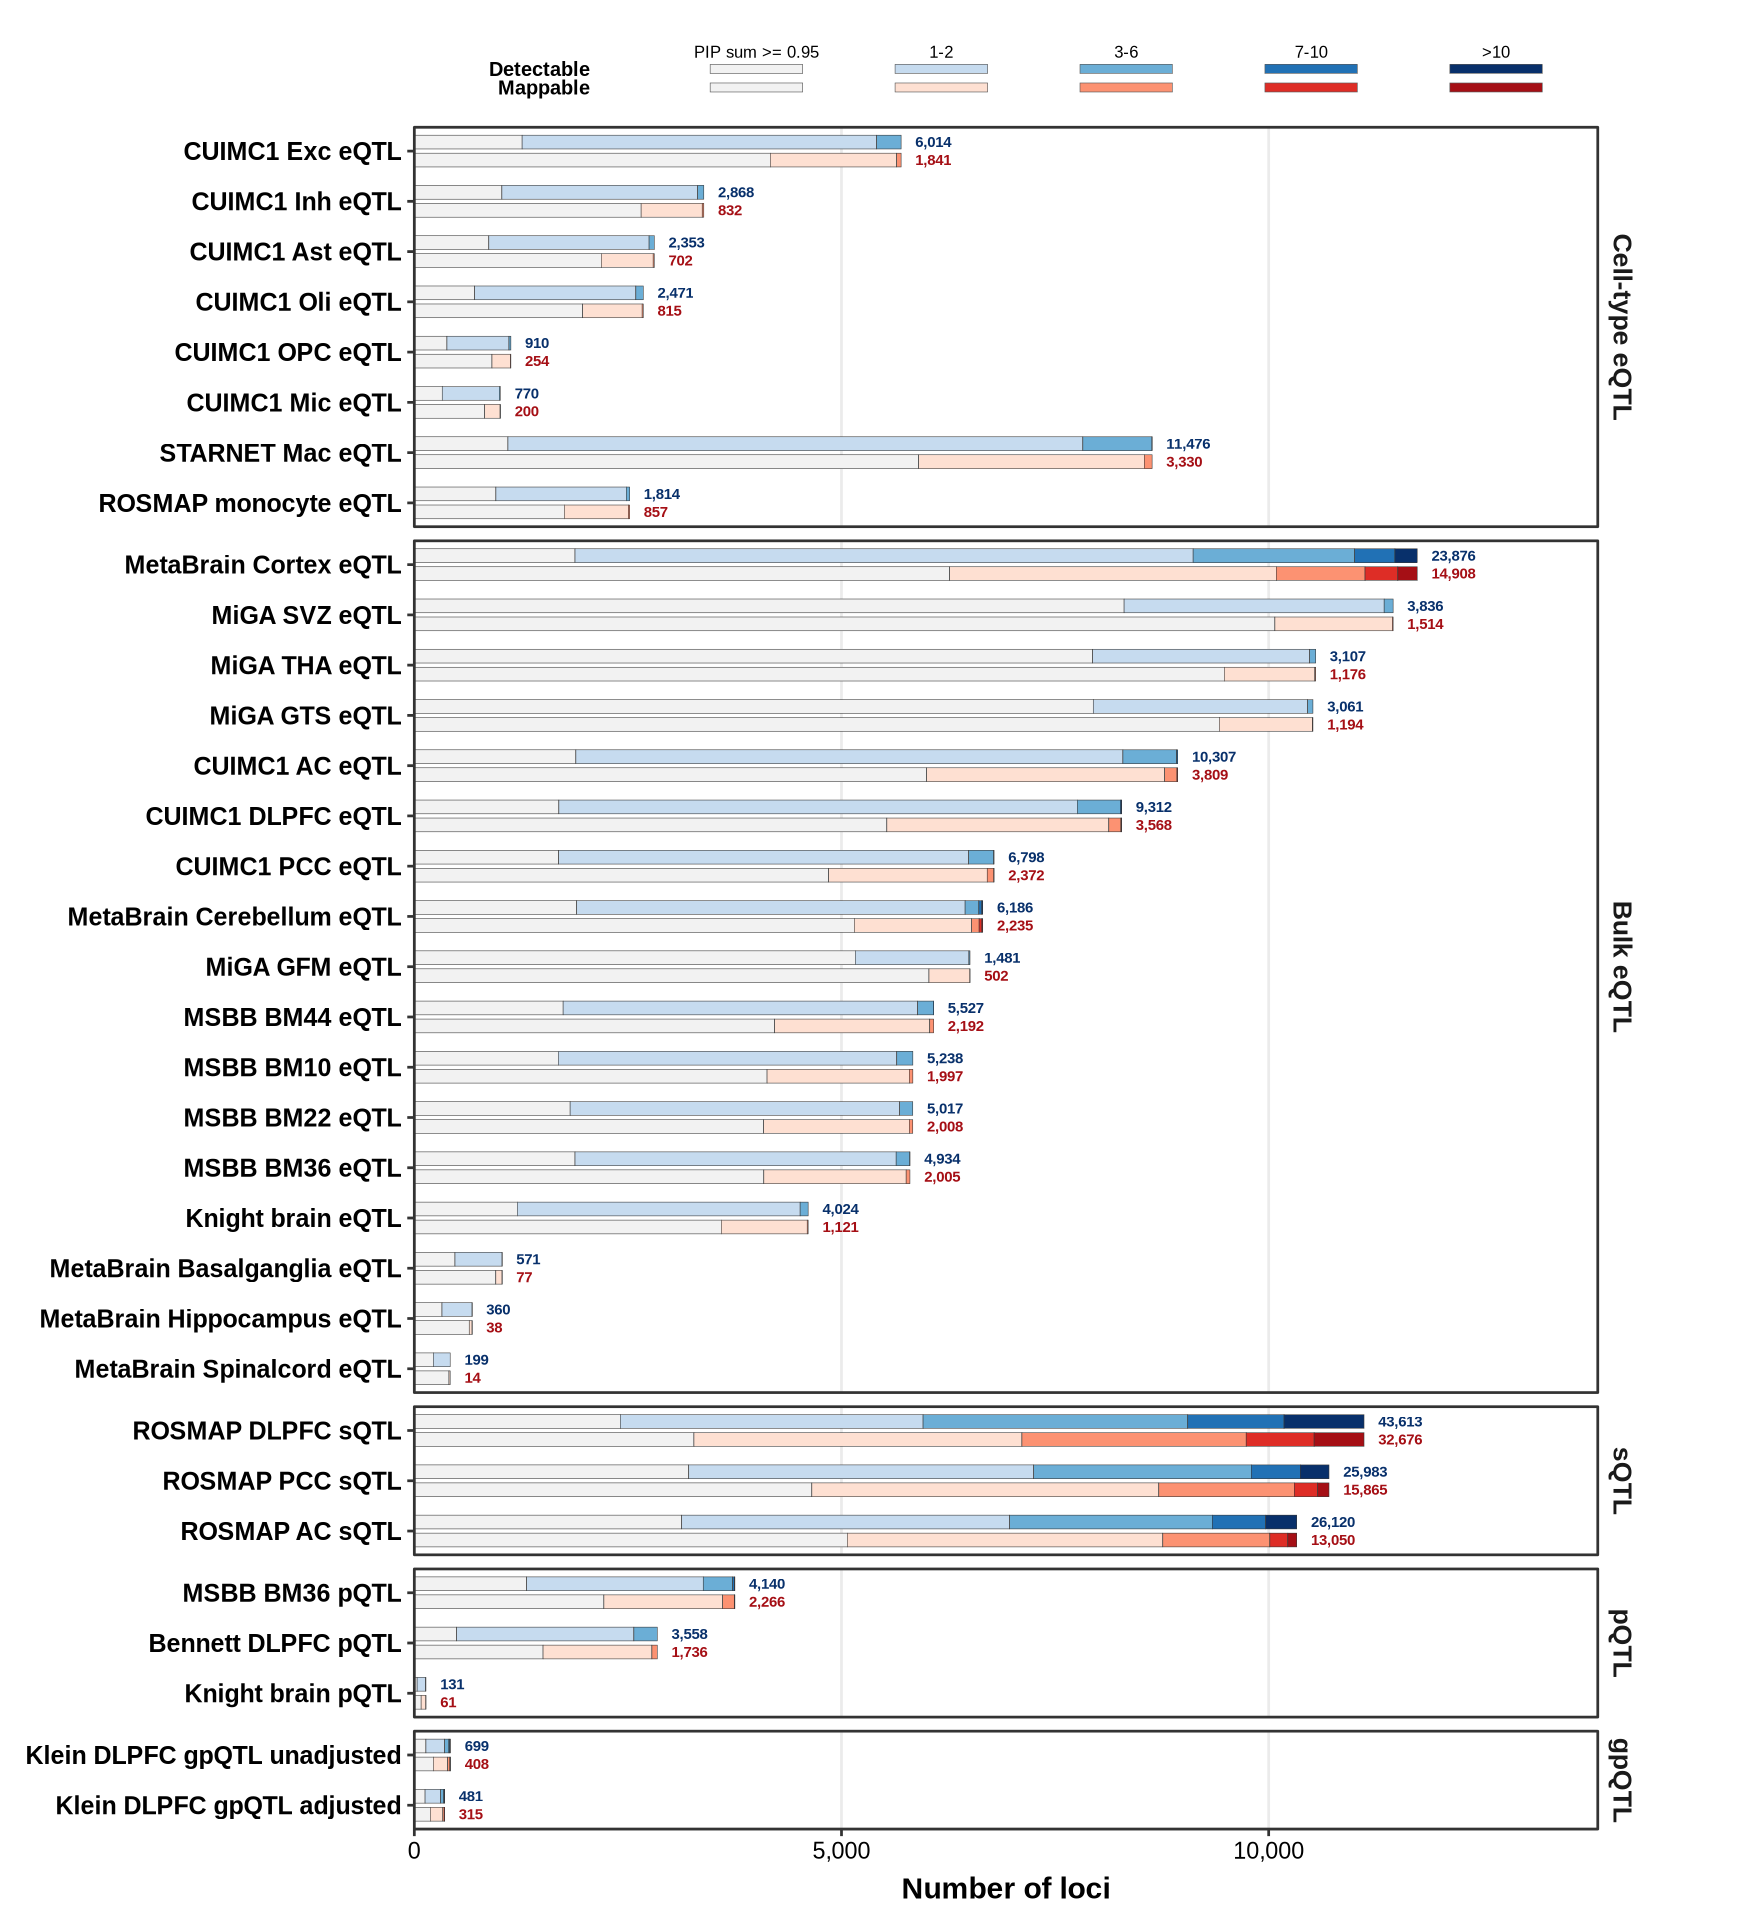

In [8]:
options(repr.plot.width = 14.5, repr.plot.height = 16)
p18_blue_red_linear_snuc_cuimc1
